# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [ ]:
%pip install pandas mlxtend matplotlib networkx

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import networkx as nx

CSV_PATH = "bread_basket.csv"
bread= pd.read_csv(CSV_PATH)

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [ ]:
bread.dtypes

transaction        int64
item                 str
date_time            str
time                 str
period_day           str
weekday_weekend      str
dtype: object

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [ ]:
bread.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

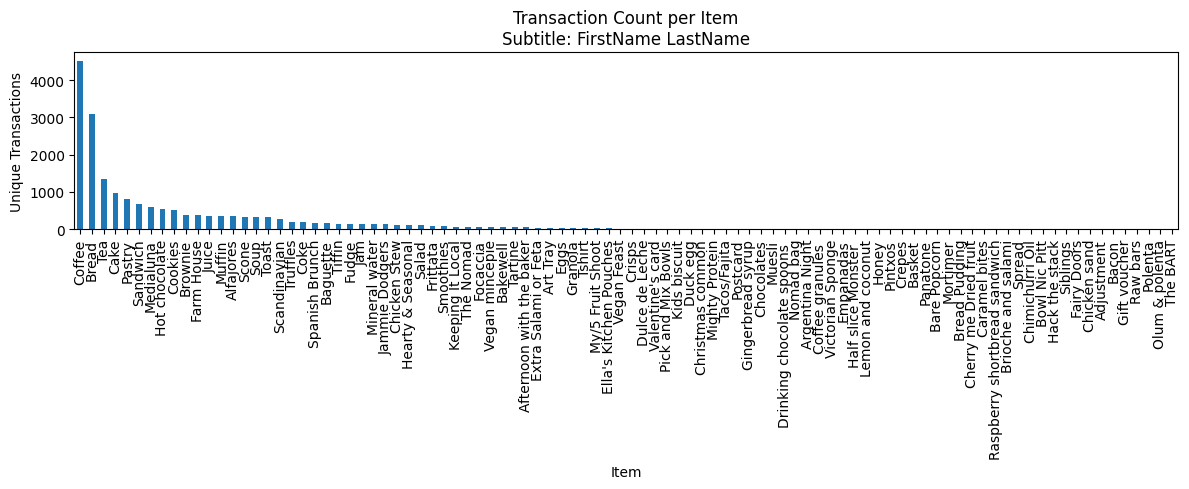

In [ ]:
# c) Bar plot of transaction counts per item
subtitle = "FirstName LastName"  # <-- EDIT THIS
item_counts = bread.groupby("item")["transaction"].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [ ]:
Item_Counts = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]
bread.groupby("item")["transaction"].nunique().loc[Item_Counts]

item
Coffee          4528
Tea             1350
Alfajores        344
Juice            365
Chicken Stew     123
Name: transaction, dtype: int64

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [ ]:
basket = (bread.groupby("transaction")["item"].apply(list)
          .reset_index()
          .sort_values("transaction")["item"]
          .tolist())
translated_basket =TransactionEncoder()
hot_basket = pd.DataFrame(translated_basket.fit(basket).transform(basket), columns=translated_basket.columns_).astype(bool)

support = .02
frequent_itemset = fpgrowth(hot_basket, min_support=support, use_colnames=True)
frequent_itemset.sort_values("support",ascending=False).head()

,support,itemsets
5,0.478394,frozenset({Coffee})
0,0.327205,frozenset({Bread})
8,0.142631,frozenset({Tea})
12,0.103856,frozenset({Cake})
19,0.090016,"frozenset({Bread, Coffee})"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [ ]:
confidence=.1
shop_rules= association_rules(frequent_itemset, metric="confidence", min_threshold=confidence)
shop_rules[["antecedents", "consequents", "support", "confidence","lift"]]

,antecedents,consequents,support,confidence,lift
0,frozenset({Bread}),frozenset({Coffee}),0.090016,0.275105,0.575059
1,frozenset({Coffee}),frozenset({Bread}),0.090016,0.188163,0.575059
2,frozenset({Hot chocolate}),frozenset({Coffee}),0.029583,0.507246,1.060311
3,frozenset({Cookies}),frozenset({Coffee}),0.028209,0.518447,1.083723
4,frozenset({Pastry}),frozenset({Coffee}),0.047544,0.552147,1.154168
5,frozenset({Pastry}),frozenset({Bread}),0.029160,0.338650,1.034977
6,frozenset({Medialuna}),frozenset({Coffee}),0.035182,0.569231,1.189878
7,frozenset({Coffee}),frozenset({Tea}),0.049868,0.104240,0.730840
8,frozenset({Tea}),frozenset({Coffee}),0.049868,0.349630,0.730840
9,frozenset({Tea}),frozenset({Bread}),0.028104,0.197037,0.602181


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*
1% of all transactions contain Coffee, Cake, and Bread sold together.
Among baskets with Coffee and Cake 18.34% also include Bread.
A lift above 1 implies there was a positive association meaning when an item is bought, another item is more likley to be bought. A negative lift means the opposite, and an item is less likley to be purchased when certain item is bought. In this case, {Coffee, Cake} ⇒ {Bread} had a negative lift, customers were less likley to buy bread if coffee and cake were already in their basket.



>

In [ ]:
h